In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda')
device

device(type='cuda')

In [2]:
seed = 42
C = np.inf

In [3]:
# make sources
z_01 = np.linspace(0, 1, 32)

# modify density
z_01 = z_01 ** 2

z_01 = np.meshgrid(z_01, z_01)
z_01 = np.stack(z_01, 0).reshape(2, -1).T
z_01 = np.concatenate([z_01, np.zeros_like(z_01[:, :1])], 1)

z_02 = np.stack([z_01[:, 0], z_01[:, 2], z_01[:, 1]], 1)
z_12 = np.stack([z_01[:, 2], z_01[:, 0], z_01[:, 1]], 1)

z_01.shape, z_02.shape, z_12.shape

((1024, 3), (1024, 3), (1024, 3))

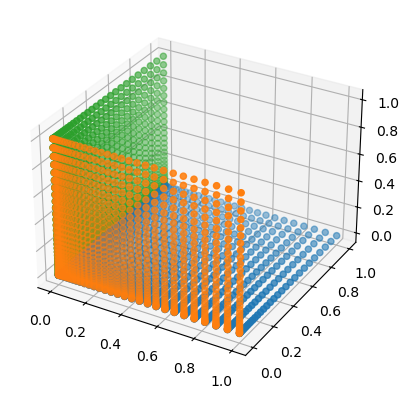

In [7]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(*z_01.T)
ax.scatter(*z_02.T)
ax.scatter(*z_12.T)

In [51]:
# random down projection
np.random.seed(42 + 0)
A = np.random.normal(0, 1, (3, 1))

In [52]:
## mixing in 1d
y_01 = z_01 @ A
y_02 = z_02 @ A
y_12 = z_12 @ A

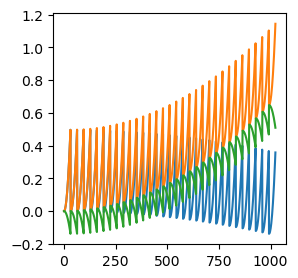

In [58]:
s = 5
plt.figure(figsize=(3, 3))
plt.plot(*y_01.T)
plt.plot(*y_02.T)
plt.plot(*y_12.T)

(array([ 69., 155., 227., 129., 101.,  89.,  81.,  71.,  61.,  41.]),
 array([-0.1382643 , -0.07476646, -0.01126861,  0.05222924,  0.11572708,
         0.17922493,  0.24272277,  0.30622062,  0.36971846,  0.43321631,
         0.49671415]),
 <BarContainer object of 10 artists>)

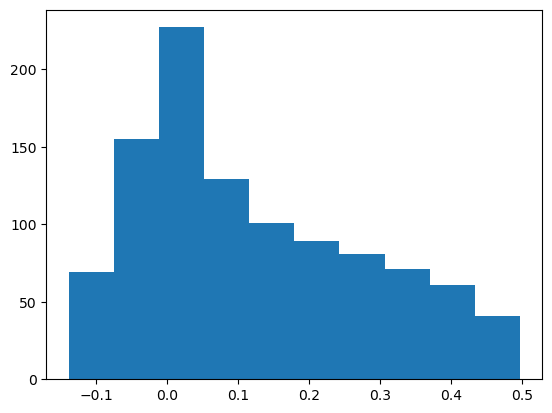

In [59]:
plt.hist(*y_01.T)

In [60]:
from sklearn.decomposition import DictionaryLearning
from sklearn.decomposition import sparse_encode

target = np.concatenate([z_01, z_12, z_02], 0)
inputs = target @ A

X_transformed = sparse_encode(inputs, A, algorithm='lasso_cd', alpha=0, positive=True)

X_transformed.shape, X_transformed.min()

/grid/klindt/home/barinpac/.conda/envs/jhub-py312/lib/python3.12/site-packages/sklearn/base.py:1363: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/grid/klindt/home/barinpac/.conda/envs/jhub-py312/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/grid/klindt/home/barinpac/.conda/envs/jhub-py312/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent_gram(


((3072, 3), np.float64(0.0))

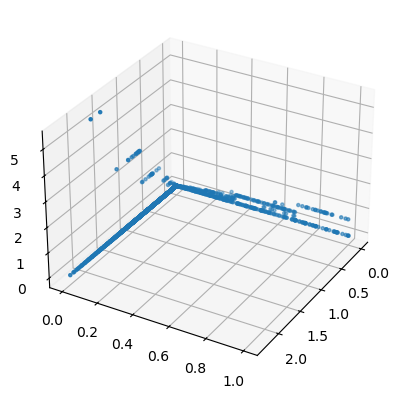

In [64]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(*X_transformed.T, s=s)
ax.view_init(elev, azim, roll)
plt.show()

In [8]:
# train A (linear encoder, nonlinear decoder)
num_seed = 10

inputs = np.concatenate([z_01, z_12, z_02], 0)
inputs = torch.tensor(inputs, dtype=torch.float32, device=device)

best_loss = np.inf
A = None

for rep in range(num_seed):
    torch.manual_seed(seed + rep)
    # MLP gets perfect
    encoder = nn.Linear(3, 2, bias=False).to(device)
    decoder = nn.Sequential(nn.Linear(2, 256), nn.ReLU(), nn.Linear(256, 3)).to(device)
    optim = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-3)

    for i in tqdm(range(10000)):
        y = encoder(inputs)
        rec = decoder(y)
        loss = torch.mean((inputs - rec) **2 )
        optim.zero_grad()
        loss.backward()
        optim.step()
    print(rep, i, loss.item())
    if loss.item() < best_loss:
        best_loss = loss.item()
        A = encoder.weight.detach().cpu().numpy().T
        if best_loss < 1e-4:
            break

100%|██████████| 10000/10000 [00:09<00:00, 1090.63it/s]

0 9999 1.1168983292009216e-05


In [9]:
# make observations
y_01 = z_01 @ A
y_02 = z_02 @ A
y_12 = z_12 @ A

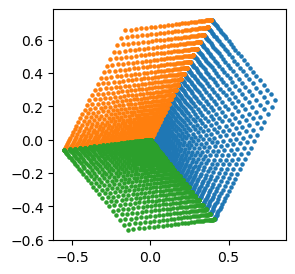

In [10]:
s = 5
plt.figure(figsize=(3, 3))
plt.scatter(*y_01.T, s=s)
plt.scatter(*y_02.T, s=s)
plt.scatter(*y_12.T, s=s)

In [12]:
z_iid = np.concatenate([z_01, z_12], 0)
z_ood = z_02
y_iid = z_iid @ A
y_ood = z_ood @ A

In [14]:
label_iid = z_iid > .5
label_ood = z_ood > .5

In [15]:
# Logistic regression in the original space
for ind in range(3):
    clf = LogisticRegression(C=C).fit(z_iid, label_iid[:, ind])
    
    acc_iid = clf.score(z_iid, label_iid[:, ind])
    acc_ood = clf.score(z_ood, label_ood[:, ind])
    print(f'index {ind}, acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

index 0, acc IID: 1.000, acc OOD: 1.000
index 1, acc IID: 1.000, acc OOD: 1.000
index 2, acc IID: 1.000, acc OOD: 1.000


In [17]:
target = np.concatenate([z_01, z_12, z_02], 0)

In [22]:
target.shape

(3072, 3)

In [23]:
x_vals

NameError: name 'x_vals' is not defined

In [26]:
len(label_ood)

1024

In [39]:
z_iid.shape

(2048, 3)

In [41]:
label_iid.shape

(2048, 3)

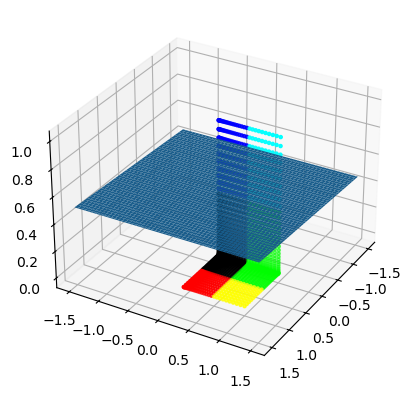

In [45]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
# ax.scatter(*z_01.T)
# ax.scatter(*z_02.T)
# ax.scatter(*z_12.T)
ax.scatter(*z_iid.T, s=s, c=label_iid)

dum = 1.5
xlim = (-dum, dum)
ylim = (-dum, dum)

x_vals = np.linspace(*xlim, 100)
y_vals = np.linspace(*ylim, 100)
x,y = np.meshgrid(x_vals,y_vals)
z = lambda x,y: (-clf.intercept_[0]-clf.coef_[0][0]*x-clf.coef_[0][1]*y) / clf.coef_[0][2]
ax.plot_surface(x, y, z(x,y))

elev = 30
azim = 30
roll = 0
ax.view_init(elev, azim, roll)
plt.show()

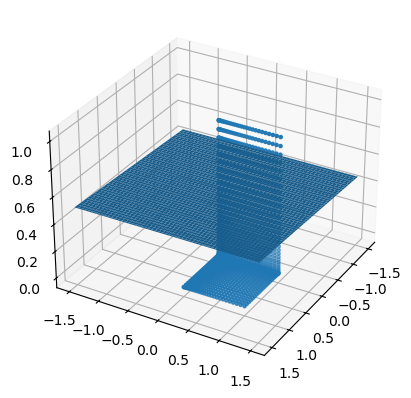

In [48]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
# ax.scatter(*z_01.T)
# ax.scatter(*z_02.T)
# ax.scatter(*z_12.T)
ax.scatter(*z_iid.T, s=s)

dum = 1.5
xlim = (-dum, dum)
ylim = (-dum, dum)

x_vals = np.linspace(*xlim, 100)
y_vals = np.linspace(*ylim, 100)
x,y = np.meshgrid(x_vals,y_vals)
z = lambda x,y: (-clf.intercept_[0]-clf.coef_[0][0]*x-clf.coef_[0][1]*y) / clf.coef_[0][2]
ax.plot_surface(x, y, z(x,y))

elev = 30
azim = 30
roll = 0
ax.view_init(elev, azim, roll)
plt.show()

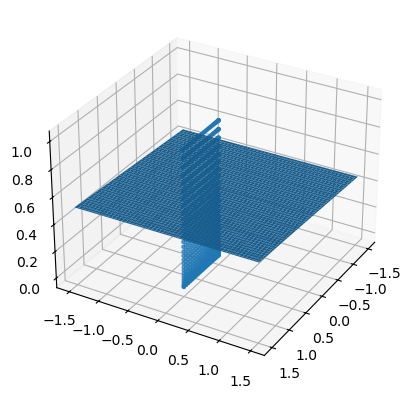

In [49]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
# ax.scatter(*z_01.T)
# ax.scatter(*z_02.T)
# ax.scatter(*z_12.T)
ax.scatter(*z_ood.T, s=s)

dum = 1.5
xlim = (-dum, dum)
ylim = (-dum, dum)

x_vals = np.linspace(*xlim, 100)
y_vals = np.linspace(*ylim, 100)
x,y = np.meshgrid(x_vals,y_vals)
z = lambda x,y: (-clf.intercept_[0]-clf.coef_[0][0]*x-clf.coef_[0][1]*y) / clf.coef_[0][2]
ax.plot_surface(x, y, z(x,y))

elev = 30
azim = 30
roll = 0
ax.view_init(elev, azim, roll)
plt.show()

In [47]:
label_iid

array([[False, False, False],
       [False, False, False],
       [False, False, False],
       ...,
       [False,  True,  True],
       [False,  True,  True],
       [False,  True,  True]])

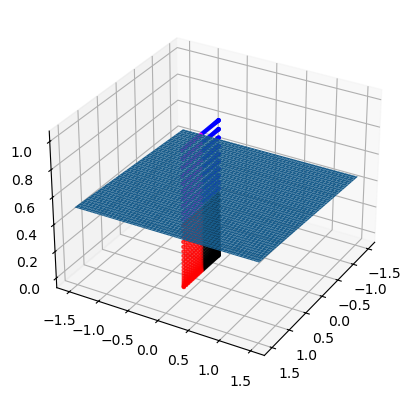

In [46]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
# ax.scatter(*z_01.T)
# ax.scatter(*z_02.T)
# ax.scatter(*z_12.T)
ax.scatter(*z_ood.T, s=s, c=label_ood)

dum = 1.5
xlim = (-dum, dum)
ylim = (-dum, dum)

x_vals = np.linspace(*xlim, 100)
y_vals = np.linspace(*ylim, 100)
x,y = np.meshgrid(x_vals,y_vals)
z = lambda x,y: (-clf.intercept_[0]-clf.coef_[0][0]*x-clf.coef_[0][1]*y) / clf.coef_[0][2]
ax.plot_surface(x, y, z(x,y))

elev = 30
azim = 30
roll = 0
ax.view_init(elev, azim, roll)
plt.show()